In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

try:
    from sqlalchemy import text
    SQLALCHEMY_OK = True
except ImportError:
    SQLALCHEMY_OK = False
    text = None
    print("sqlalchemy no disponible - solo se podra cargar desde Excel")

sys.path.append('.')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Configuración de Fuente de Datos
Elige si quieres leer de los Excels locales o de la Base de Datos. Por defecto usamos los Excel.

In [2]:
USE_DB = False  # Cambia a True si deseas conectarte a la base de datos mediante db.py

engine = None
if USE_DB:
    from db import get_engine
    try:
        engine = get_engine()
        print("Conexion exitosa a la base de datos.")
    except Exception as e:
        print(f"Error al conectar a la BD: {e}")
else:
    print("Se utilizaran los archivos locales de Excel en la carpeta 'data/'.")

Se utilizaran los archivos locales de Excel en la carpeta 'data/'.


## 2. Carga de Datos de Ventas Granulares
Se cargan las ventas históricas agrupadas por mes, segmento, marca, modelo y provincia.

In [3]:
ventas_industria = None

if USE_DB and SQLALCHEMY_OK and engine is not None:
    sql_sales = """
    SELECT 
        fecha_proceso as Fecha,
        segmento,
        marca,
        modelo,
        provincia,
        SUM(unidades) as Ventas
    FROM sales_granular
    GROUP BY 1, 2, 3, 4, 5
    """
    try:
        ventas_industria = pd.read_sql(text(sql_sales), engine)
        # Algunos drivers (ej. PostgreSQL) devuelven nombres de columna en minusculas
        ventas_industria.columns = [
            'Fecha' if c.lower() == 'fecha' else
            'Ventas' if c.lower() == 'ventas' else c
            for c in ventas_industria.columns
        ]
        ventas_industria['Fecha'] = pd.to_datetime(ventas_industria['Fecha']).dt.to_period('M').dt.to_timestamp()
        print(f"Ventas cargadas desde BD: {ventas_industria.shape[0]} registros.")
    except Exception as e:
        print(f"Error cargando ventas desde BD: {e} - intentando con Excel...")
        ventas_industria = None

if ventas_industria is None:
    try:
        ruta_ventas = os.path.join('data', 'ventas_total.xlsx')
        print(f"Leyendo archivo: {ruta_ventas} ...")
        df_raw = pd.read_excel(ruta_ventas)

        df_raw.columns = [c.strip().lower().replace(" ", "_") for c in df_raw.columns]

        if 'unidades' in df_raw.columns:
            df_raw['unidades'] = pd.to_numeric(df_raw['unidades'], errors='coerce').fillna(0)

        # Truncar a inicio de mes antes de agrupar (igual que en la query de BD)
        df_raw['Fecha'] = pd.to_datetime(df_raw['fecha_proceso'], errors='coerce').dt.to_period('M').dt.to_timestamp()
        df_raw = df_raw.dropna(subset=['Fecha'])

        cols_grupo = ['Fecha', 'segmento', 'marca', 'modelo', 'provincia']
        cols_presentes = [c for c in cols_grupo if c in df_raw.columns]

        if 'unidades' in df_raw.columns:
            ventas_industria = df_raw.groupby(cols_presentes, as_index=False)['unidades'].sum()
            ventas_industria = ventas_industria.rename(columns={'unidades': 'Ventas'})
        else:
            ventas_industria = df_raw[cols_presentes].copy()

        print(f"Ventas cargadas desde Excel: {ventas_industria.shape[0]} registros.")
    except Exception as e:
        print(f"Error cargando ventas desde Excel: {e}")

if ventas_industria is not None:
    display(ventas_industria.head())
else:
    print("No se pudo cargar ventas_industria - verifica las rutas y la conexion.")

Leyendo archivo: data\ventas_total.xlsx ...
Ventas cargadas desde Excel: 164049 registros.


,Fecha,segmento,marca,modelo,provincia,Ventas
0,2020-01-01,AUTOMOVIL,AUDI,A4 TFSI 8W2AEG STRONIC STD AC 1.4 4P 4X2 TA,PICHINCHA,5
1,2020-01-01,AUTOMOVIL,BMW,118I AC 1.5 5P 4X2 TA,PICHINCHA,1
2,2020-01-01,AUTOMOVIL,BMW,320I AC 2.0 4P 4X2 TA,GUAYAS,3
3,2020-01-01,AUTOMOVIL,BMW,320I AC 2.0 4P 4X2 TA,PICHINCHA,3
4,2020-01-01,AUTOMOVIL,BMW,320I AC 2.0 4P 4X2 TA,TUNGURAHUA,1


## 3. Carga de Drivers Macroeconómicos
Extraemos la información de los drivers y normalizamos los nombres de las columnas.

In [4]:
variables_macro = None

if USE_DB and SQLALCHEMY_OK and engine is not None:
    sql_drivers = "SELECT * FROM historical_drivers"
    try:
        variables_macro = pd.read_sql(text(sql_drivers), engine)
        # Normalizar columna de fecha (algunos drivers devuelven nombres en minusculas)
        variables_macro.columns = [
            'Fecha' if c.lower() == 'fecha' else c
            for c in variables_macro.columns
        ]
        variables_macro['Fecha'] = pd.to_datetime(variables_macro['Fecha'])
        print(f"Variables macro cargadas desde BD: {variables_macro.shape[0]} meses.")
    except Exception as e:
        print(f"Error cargando variables macro desde BD: {e} - intentando con Excel...")
        variables_macro = None

if variables_macro is None:
    try:
        ruta_drivers = os.path.join('data', 'Variables.xlsx')
        variables_macro = pd.read_excel(ruta_drivers)
        variables_macro['Fecha'] = pd.to_datetime(variables_macro['Fecha'], errors='coerce')
        print(f"Variables macro cargadas desde Excel: {variables_macro.shape[0]} meses.")
    except Exception as e:
        print(f"Error cargando variables macro desde Excel: {e}")

if variables_macro is not None:
    variables_macro.columns = [
        col.replace(' ', '_').replace('/', '_').replace('.', '_')
        for col in variables_macro.columns
    ]
    display(variables_macro.head())
else:
    print("No se pudo cargar variables_macro - verifica las rutas y la conexion.")

Variables macro cargadas desde Excel: 135 meses.


,Fecha,IVA,WTI,euro_usd,PVP_ORO_1_OZ,PIB_BRU,PIB_DEM_CAD_BRU,GASTO_CONSUMO_FINAL_BRU,IMP_BIENES_SERV_BRU,FBKF,DEMINT_BRU,DEMINT_CORR_AJUS,PIB_CAD_AJUS,ING_PETROLEO,PETRO_PROD,IPC,InflacionMensual,CreditoSectorPrivado,DepositosAlaVista,ICC,EmpleoAdecuadoPleno,IMP_CBU,Riesgo_Pais,Tasa_de_Interes_Activa,Cartera_Creditos_de_Consumo,Utilidades,Paro,CUP_IMPORT,Elec_Presidenciales,Cambio_IVA,DUMMY_COVID_LOCKDOWN
0,2015-01-01,0.12,48.24,1.1286,1279.2,7.710650e+06,8.083908e+06,5.002169e+06,2.264722e+06,1.725134e+06,7.966299e+06,8.506955e+06,8.554330e+06,8.340412e+05,17289.41066,101.238093,0.005904,29358.861447,8697.4,46.5,0.437206,8352.44,943,7.84,6.900909e+09,0,0.0,1,0,0,0
1,2015-02-01,0.12,49.76,1.1193,1213.1,7.710650e+06,8.083908e+06,5.002169e+06,2.264722e+06,1.725134e+06,7.966299e+06,8.506955e+06,8.554330e+06,7.706592e+05,15487.52444,101.858066,0.006124,29768.972127,8426.4,48.1,0.437206,4528.00,779,7.41,6.884104e+09,0,0.0,1,0,0,0
2,2015-03-01,0.12,47.60,1.0730,1183.2,7.710650e+06,8.083908e+06,5.002169e+06,2.264722e+06,1.725134e+06,7.966299e+06,8.506955e+06,8.554330e+06,8.155990e+05,17134.43327,102.279947,0.004142,29840.700819,8720.3,44.3,0.437206,4142.00,801,7.31,6.898492e+09,0,0.0,1,0,0,0
3,2015-04-01,0.12,59.63,1.1222,1182.4,7.969951e+06,8.121363e+06,5.116115e+06,2.072031e+06,1.742379e+06,8.064397e+06,8.366408e+06,8.301624e+06,9.801263e+05,16436.79869,103.136276,0.008372,29942.437610,7936.8,45.8,0.437206,3028.00,780,8.09,6.818364e+09,1,0.0,1,0,0,0
4,2015-05-01,0.12,60.30,1.0987,1189.8,7.969951e+06,8.121363e+06,5.116115e+06,2.072031e+06,1.742379e+06,8.064397e+06,8.366408e+06,8.301624e+06,1.015389e+06,16838.94851,103.318855,0.001770,29758.155083,8006.0,46.7,0.437206,1840.00,668,8.45,6.769414e+09,0,0.0,1,0,0,0


In [5]:
# Enriquecimiento con Variables_trimestral.xlsx (interpolacion trimestral -> mensual)
ruta_trimestral = os.path.join('data', 'Variables_trimestral.xlsx')
if os.path.exists(ruta_trimestral):
    try:
        df_trim = pd.read_excel(ruta_trimestral)
        df_trim.columns = [
            'Fecha' if c.strip().lower() == 'fecha' else
            c.strip().replace(' ', '_').replace('/', '_').replace('.', '_')
            for c in df_trim.columns
        ]
        df_trim['Fecha'] = pd.to_datetime(df_trim['Fecha'], errors='coerce')
        df_trim = df_trim.dropna(subset=['Fecha']).set_index('Fecha').sort_index()
        cols_trim = [c for c in df_trim.columns if c in variables_macro.columns]
        if cols_trim:
            vm = variables_macro.set_index('Fecha')
            idx_mensual = pd.date_range(
                start=df_trim.index.min(),
                end=vm.index.max(),
                freq='MS'
            )
            df_trim_mensual = (
                df_trim[cols_trim]
                .reindex(idx_mensual)
                .interpolate(method='cubic')
                .ffill()
            )
            df_trim_mensual.index.name = 'Fecha'
            vm.update(df_trim_mensual)
            variables_macro = vm.reset_index()
            print(f"Interpolacion trimestral -> mensual aplicada en: {cols_trim}")
        else:
            print("Sin columnas en comun entre Variables_trimestral.xlsx y variables_macro.")
    except PermissionError:
        print(f"AVISO: {ruta_trimestral} esta bloqueado (cerrarlo en Excel). Se omite enriquecimiento trimestral.")
    except Exception as e:
        print(f"AVISO: No se pudo leer Variables_trimestral.xlsx: {e}")
else:
    print("Variables_trimestral.xlsx no encontrado - se usan solo los datos de la fuente principal.")
display(variables_macro.head(3))

Interpolación trimestral -> mensual aplicada en: ['PIB_BRU', 'GASTO_CONSUMO_FINAL_BRU', 'IMP_BIENES_SERV_BRU', 'FBKF', 'DEMINT_BRU']
   Rango cubierto: 2015-01-01 -> 2026-03-01
   Último valor trimestral (2025-10-01) replicado hacia adelante donde aplica.


,Fecha,IVA,WTI,euro_usd,PVP_ORO_1_OZ,PIB_BRU,PIB_DEM_CAD_BRU,GASTO_CONSUMO_FINAL_BRU,IMP_BIENES_SERV_BRU,FBKF,DEMINT_BRU,DEMINT_CORR_AJUS,PIB_CAD_AJUS,ING_PETROLEO,PETRO_PROD,IPC,InflacionMensual,CreditoSectorPrivado,DepositosAlaVista,ICC,EmpleoAdecuadoPleno,IMP_CBU,Riesgo_Pais,Tasa_de_Interes_Activa,Cartera_Creditos_de_Consumo,Utilidades,Paro,CUP_IMPORT,Elec_Presidenciales,Cambio_IVA,DUMMY_COVID_LOCKDOWN
0,2015-01-01,0.12,48.24,1.1286,1279.2,2.313195e+07,8.083908e+06,1.500651e+07,6.794165e+06,5.175401e+06,2.389890e+07,8.506955e+06,8.554330e+06,834041.170238,17289.41066,101.238093,0.005904,29358.861447,8697.4,46.5,0.437206,8352.44,943,7.84,6.900909e+09,0,0.0,1,0,0,0
1,2015-02-01,0.12,49.76,1.1193,1213.1,2.396338e+07,8.083908e+06,1.542085e+07,6.551205e+06,5.359939e+06,2.437715e+07,8.506955e+06,8.554330e+06,770659.216134,15487.52444,101.858066,0.006124,29768.972127,8426.4,48.1,0.437206,4528.00,779,7.41,6.884104e+09,0,0.0,1,0,0,0
2,2015-03-01,0.12,47.60,1.0730,1183.2,2.411576e+07,8.083908e+06,1.547773e+07,6.374053e+06,5.343877e+06,2.439678e+07,8.506955e+06,8.554330e+06,815599.023652,17134.43327,102.279947,0.004142,29840.700819,8720.3,44.3,0.437206,4142.00,801,7.31,6.898492e+09,0,0.0,1,0,0,0


## 4. Análisis Exploratorio

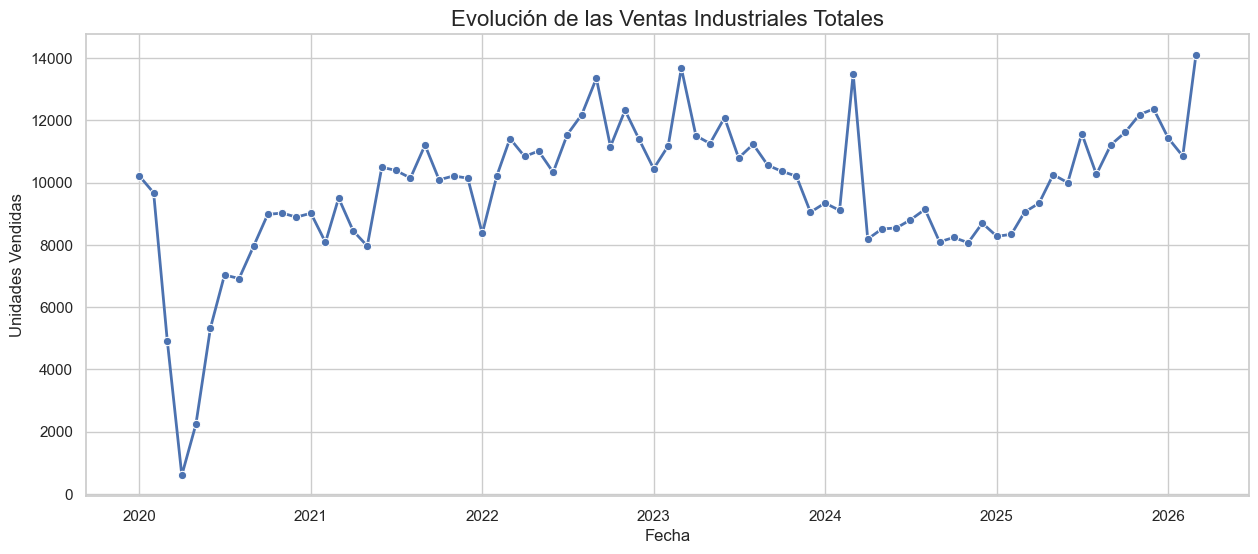

In [17]:
# Serie de Tiempo: Ventas Totales por Mes
df_ventas_totales = ventas_industria.groupby('Fecha')['Ventas'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_ventas_totales, x='Fecha', y='Ventas', marker="o", linewidth=2)
plt.title('Evolución de las Ventas Industriales Totales', fontsize=16)
plt.ylabel('Unidades Vendidas')
plt.xlabel('Fecha')
plt.show()

C:\Users\sbonilla\AppData\Local\Temp\ipykernel_29048\1036248129.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segmentos, x='Ventas', y='segmento', palette='viridis')


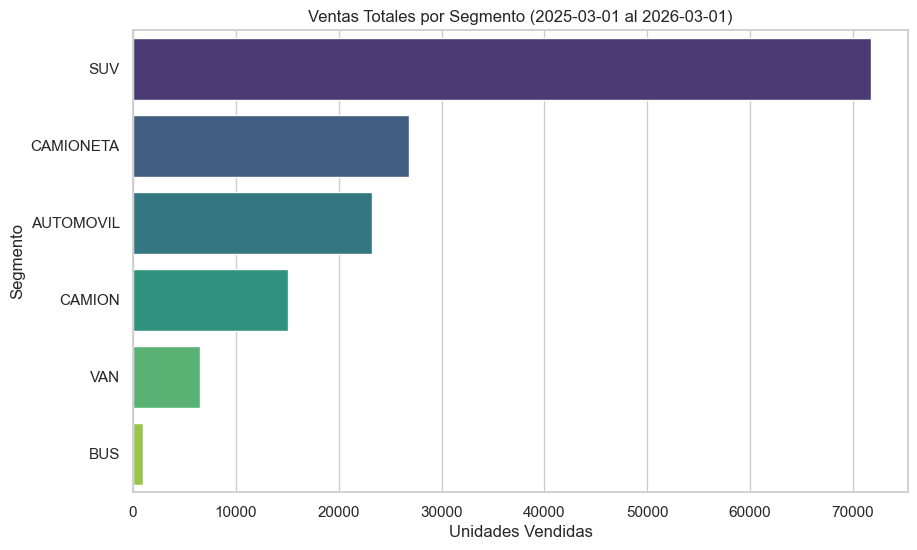

In [ ]:
# Distribución de Ventas por Segmento (Ãšltimo AÃ±o Disponible)
if 'segmento' in ventas_industria.columns:
    max_date = ventas_industria['Fecha'].max()
    last_year_date = max_date - pd.DateOffset(years=1)

    df_last_year = ventas_industria[ventas_industria['Fecha'] >= last_year_date]
    df_segmentos = df_last_year.groupby('segmento')['Ventas'].sum().reset_index().sort_values('Ventas', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_segmentos, x='Ventas', y='segmento', palette='viridis')
    plt.title(f'Ventas Totales por Segmento ({last_year_date.date()} al {max_date.date()})')
    plt.xlabel('Unidades Vendidas')
    plt.ylabel('Segmento')
    plt.show()

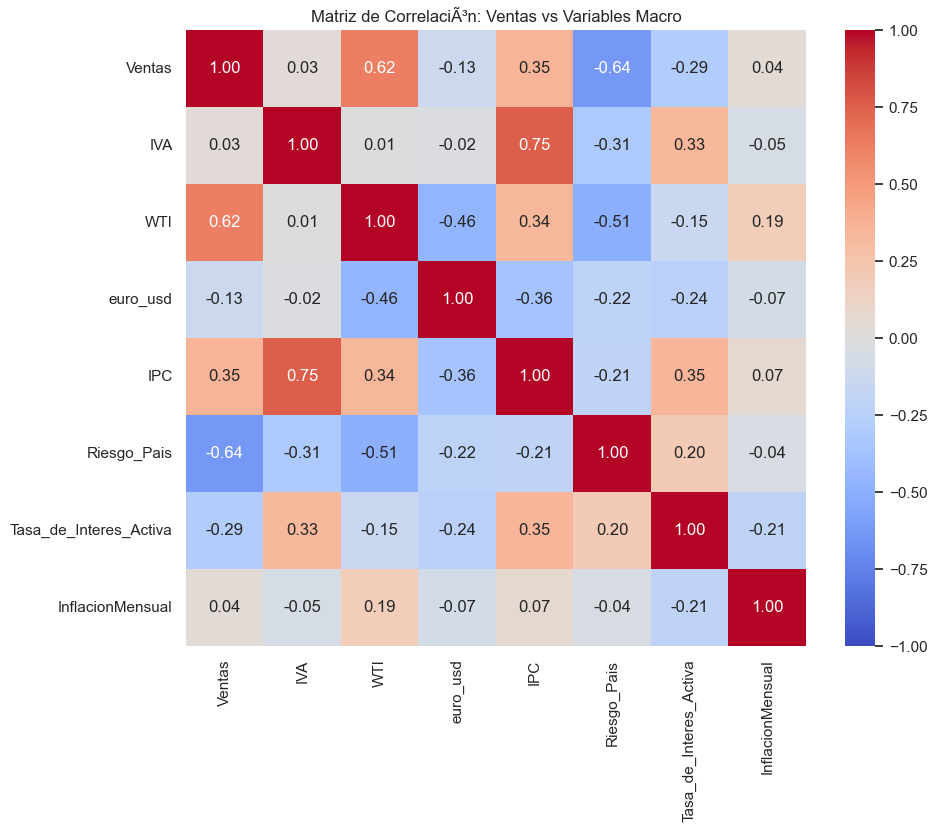

In [ ]:
# Correlación Inicial (Ventas Totales vs Variables Macro)
if 'variables_macro' in locals() and not df_ventas_totales.empty:
    df_merged = pd.merge(df_ventas_totales, variables_macro, on='Fecha', how='inner')
    cols_to_correlate = ['Ventas', 'IVA', 'WTI', 'euro_usd', 'IPC', 'Riesgo_Pais', 'Tasa_de_Interes_Activa', 'InflacionMensual']
    cols_existentes = [c for c in cols_to_correlate if c in df_merged.columns]
    
    if len(cols_existentes) < 3:
        numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
        cols_existentes = numeric_cols[:10] if len(numeric_cols) > 10 else numeric_cols

    if len(cols_existentes) > 1:
        corr_matrix = df_merged[cols_existentes].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Matriz de Correlación: Ventas vs Variables Macro')
        plt.show()

## 5. Modelo Predictivo de Ventas Industria
**Arquitectura:**
- **LSTM lag-only** (Opción A): predice ventas usando Ãºnicamente histórico de ventas sin variables externas
- **LSTM por variable macro**: proyecta cada variable macro individualmente para el horizonte futuro
- **XGBoost y RandomForest**: usan lags de ventas + macro proyectada via LSTM
- **Comparación de modelos** con mÃ©tricas MAE, RMSE, MAPE y grÃ¡ficos Plotly interactivos

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error)

try:
    import xgboost as xgb
    USE_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False
    print("XGBoost no disponible, se usara GradientBoosting")

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(42)
    USE_LSTM = True
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    USE_LSTM = False
    print("TensorFlow no disponible - se omitira LSTM")

# --- Parametros globales ---
N_STEPS      = 12    # ventana de secuencias LSTM
N_FUTURO     = 6     # meses a predecir
MESES_TEST   = 12    # meses de test
RANDOM_STATE = 42
LAGS         = [1, 2, 3, 6, 12]

# --- Control de rango de datos para entrenamiento ---
# None    : usa todos los datos disponibles
# 'YYYY-MM-DD' : recorta los datos hasta ese mes inclusive (e.g. '2024-12-01')
FECHA_CORTE = '2025-12-31'

TensorFlow 2.21.0


In [31]:
# 5.1 Dataset maestro

VARS_MACRO_SEL = [
    'IVA', 'WTI', 'euro_usd', 'PVP_ORO_1_OZ', 'PIB_BRU',
    'ING_PETROLEO', 'DEMINT_BRU', 'InflacionMensual',
    'CreditoSectorPrivado', 'DepositosAlaVista', 'ICC',
    'EmpleoAdecuadoPleno', 'IMP_CBU', 'Riesgo_Pais',
    'Tasa_de_Interes_Activa', 'Cartera_Creditos_de_Consumo', 'Utilidades',
    'Paro', 'CUP_IMPORT', 'Elec_Presidenciales', 'DUMMY_COVID_LOCKDOWN',
    'GASTO_CONSUMO_FINAL_BRU', 'IMP_BIENES_SERV_BRU', 'FBKF'
]

vars_disponibles = [v for v in VARS_MACRO_SEL if v in variables_macro.columns]
vars_faltantes   = [v for v in VARS_MACRO_SEL if v not in variables_macro.columns]
if vars_faltantes:
    print(f"Variables no encontradas en el dataset: {vars_faltantes}")

variables_macro_fil = variables_macro[['Fecha'] + vars_disponibles].copy()
print(f"Variables macro filtradas: {len(vars_disponibles)} de {len(VARS_MACRO_SEL)} seleccionadas")
print(f"Disponibles: {vars_disponibles}")

df_ventas_mes = ventas_industria.groupby('Fecha')['Ventas'].sum().reset_index()

df_modelo = pd.merge(df_ventas_mes, variables_macro_fil, on='Fecha', how='left')
df_modelo = df_modelo.sort_values('Fecha').reset_index(drop=True)

# Aplicar corte de datos si se especifico una fecha limite
if FECHA_CORTE is not None:
    fecha_limite = pd.Timestamp(FECHA_CORTE)
    df_modelo = df_modelo[df_modelo['Fecha'] <= fecha_limite].reset_index(drop=True)
    print(f"Datos recortados hasta: {fecha_limite.date()} -- {len(df_modelo)} meses disponibles")
else:
    print(f"Usando todos los datos disponibles -- {len(df_modelo)} meses")

thresh = int(len(df_modelo) * 0.5)
df_modelo = df_modelo.dropna(axis=1, thresh=thresh)

cols_macro = [c for c in df_modelo.columns
              if c not in ('Fecha', 'Ventas') and pd.api.types.is_numeric_dtype(df_modelo[c])]

print(f"Dataset maestro: {df_modelo.shape[0]} meses | {len(cols_macro)} variables macro activas")
print(f"Rango: {df_modelo['Fecha'].min().date()} -> {df_modelo['Fecha'].max().date()}")
display(df_modelo.tail(3))

Variables macro filtradas: 24 de 24 seleccionadas
Disponibles: ['IVA', 'WTI', 'euro_usd', 'PVP_ORO_1_OZ', 'PIB_BRU', 'ING_PETROLEO', 'DEMINT_BRU', 'InflacionMensual', 'CreditoSectorPrivado', 'DepositosAlaVista', 'ICC', 'EmpleoAdecuadoPleno', 'IMP_CBU', 'Riesgo_Pais', 'Tasa_de_Interes_Activa', 'Cartera_Creditos_de_Consumo', 'Utilidades', 'Paro', 'CUP_IMPORT', 'Elec_Presidenciales', 'DUMMY_COVID_LOCKDOWN', 'GASTO_CONSUMO_FINAL_BRU', 'IMP_BIENES_SERV_BRU', 'FBKF']
Datos recortados hasta: 2025-12-31 -- 72 meses disponibles
Dataset maestro: 72 meses | 24 variables macro activas
Rango: 2020-01-01 -> 2025-12-01


,Fecha,Ventas,IVA,WTI,euro_usd,PVP_ORO_1_OZ,PIB_BRU,ING_PETROLEO,DEMINT_BRU,InflacionMensual,CreditoSectorPrivado,DepositosAlaVista,ICC,EmpleoAdecuadoPleno,IMP_CBU,Riesgo_Pais,Tasa_de_Interes_Activa,Cartera_Creditos_de_Consumo,Utilidades,Paro,CUP_IMPORT,Elec_Presidenciales,DUMMY_COVID_LOCKDOWN,GASTO_CONSUMO_FINAL_BRU,IMP_BIENES_SERV_BRU,FBKF
69,2025-10-01,11613,0.15,62.460000,1.173400,4013.300000,3.499760e+07,835322.958615,3.439946e+07,0.002787,73126.960,11779.900350,36.63,0.374100,10331.0,670,7.84,2.036328e+10,0,0.0,0,0,0,2.294079e+07,1.020879e+07,7.029451e+06
70,2025-11-01,12189,0.15,61.400000,1.153600,4254.900000,3.499760e+07,801697.679412,3.439946e+07,-0.004430,73458.444,11489.662823,37.46,0.370000,11095.0,554,7.76,2.049194e+10,0,0.0,0,0,0,2.294079e+07,1.020879e+07,7.029451e+06
71,2025-12-01,12368,0.15,57.419998,1.174729,4325.600098,3.499760e+07,928805.977694,3.439946e+07,0.000785,71180.600,11860.373435,38.35,0.351045,10037.0,756,8.17,2.010144e+10,0,0.0,0,0,0,2.294079e+07,1.020879e+07,7.029451e+06


In [32]:
# 5.2 LSTM - Forecast directo de ventas (Opcion A, sin variables macro)

def build_sequences(series, n_steps):
    X, y = [], []
    for i in range(n_steps, len(series)):
        X.append(series[i - n_steps:i])
        y.append(series[i])
    return np.array(X), np.array(y)

resultados_lstm = None
fechas_futuras  = [df_modelo['Fecha'].max() + pd.DateOffset(months=i+1)
                   for i in range(N_FUTURO)]

if USE_LSTM:
    ventas_arr = df_modelo['Ventas'].values.reshape(-1, 1)
    scaler_v   = MinMaxScaler()
    v_scaled   = scaler_v.fit_transform(ventas_arr).flatten()

    X_seq, y_seq = build_sequences(v_scaled, N_STEPS)
    X_seq = X_seq.reshape(*X_seq.shape, 1)

    corte_lstm = len(X_seq) - MESES_TEST
    X_tr, X_te = X_seq[:corte_lstm], X_seq[corte_lstm:]
    y_tr, y_te = y_seq[:corte_lstm], y_seq[corte_lstm:]

    lstm_v = Sequential([
        LSTM(64, return_sequences=True, input_shape=(N_STEPS, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    lstm_v.compile(optimizer='adam', loss='mse')
    lstm_v.fit(
        X_tr, y_tr, epochs=200, batch_size=8,
        validation_data=(X_te, y_te),
        callbacks=[EarlyStopping(monitor='val_loss', patience=15,
                                 restore_best_weights=True)],
        verbose=0
    )

    # Evaluacion en test
    y_pred_s   = lstm_v.predict(X_te, verbose=0).flatten()
    y_pred_lst = scaler_v.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_real_lst = scaler_v.inverse_transform(y_te.reshape(-1,1)).flatten()
    fechas_test_lstm = df_modelo['Fecha'].iloc[N_STEPS + corte_lstm:].reset_index(drop=True)

    # Forecast iterativo
    hist_v = list(v_scaled)
    preds_fut_s = []
    for _ in range(N_FUTURO):
        seq = np.array(hist_v[-N_STEPS:]).reshape(1, N_STEPS, 1)
        p   = lstm_v.predict(seq, verbose=0)[0][0]
        preds_fut_s.append(p)
        hist_v.append(p)

    preds_lstm_fut = scaler_v.inverse_transform(
        np.array(preds_fut_s).reshape(-1,1)).flatten()

    resultados_lstm = dict(
        fechas_test  = fechas_test_lstm,
        y_real_test  = y_real_lst,
        y_pred_test  = y_pred_lst,
        preds_futuras = preds_lstm_fut,
        mae  = mean_absolute_error(y_real_lst, y_pred_lst),
        rmse = float(np.sqrt(mean_squared_error(y_real_lst, y_pred_lst))),
        mape = mean_absolute_percentage_error(y_real_lst, y_pred_lst) * 100
    )
    print(f"LSTM lag-only | MAE: {resultados_lstm['mae']:,.0f} | "
          f"RMSE: {resultados_lstm['rmse']:,.0f} | MAPE: {resultados_lstm['mape']:.1f}%")
else:
    print("LSTM omitido - TensorFlow no disponible")

LSTM lag-only | MAE: 1,184 | RMSE: 1,339 | MAPE: 11.2%


In [ ]:
# 5.3 LSTM - Proyeccion individual de variables macro

macro_proyectada = {}

if USE_LSTM:
    for col in cols_macro:
        serie = (df_modelo[col]
                 .fillna(method='ffill')
                 .fillna(method='bfill')
                 .values.reshape(-1, 1))

        # Si hay muy pocos datos, carry-forward
        if len(serie) < N_STEPS + 10:
            macro_proyectada[col] = np.full(N_FUTURO, float(serie[-1]))
            continue

        sc_m   = MinMaxScaler()
        s_sc   = sc_m.fit_transform(serie).flatten()
        Xm, ym = build_sequences(s_sc, N_STEPS)
        Xm     = Xm.reshape(*Xm.shape, 1)

        lstm_m = Sequential([
            LSTM(32, input_shape=(N_STEPS, 1)),
            Dense(1)
        ])
        lstm_m.compile(optimizer='adam', loss='mse')
        lstm_m.fit(Xm, ym, epochs=100, batch_size=8,
                   callbacks=[EarlyStopping(monitor='loss', patience=10,
                                            restore_best_weights=True)],
                   verbose=0)

        hist_m = list(s_sc)
        preds_m = []
        for _ in range(N_FUTURO):
            seq = np.array(hist_m[-N_STEPS:]).reshape(1, N_STEPS, 1)
            p   = lstm_m.predict(seq, verbose=0)[0][0]
            preds_m.append(p)
            hist_m.append(p)

        macro_proyectada[col] = sc_m.inverse_transform(
            np.array(preds_m).reshape(-1,1)).flatten()

    print(f"Variables macro proyectadas via LSTM: {list(macro_proyectada.keys())}")
else:
    # Fallback carry-forward si no hay LSTM
    for col in cols_macro:
        macro_proyectada[col] = np.full(N_FUTURO, float(df_modelo[col].iloc[-1]))
    print("Macro proyectada por carry-forward (LSTM no disponible)")

# DataFrame con macro proyectada para el horizonte futuro
df_macro_futuro = pd.DataFrame({'Fecha': fechas_futuras, **macro_proyectada})

# Visualizacion de proyecciones macro (Plotly)
fig_macro = make_subplots(
    rows=-(-len(cols_macro)//3), cols=3,
    subplot_titles=cols_macro,
    shared_xaxes=False
)
for idx, col in enumerate(cols_macro):
    r, c = divmod(idx, 3)
    # Historico
    fig_macro.add_trace(go.Scatter(
        x=df_modelo['Fecha'], y=df_modelo[col],
        name=col, line=dict(width=1.5), showlegend=False
    ), row=r+1, col=c+1)
    # Proyeccion
    fig_macro.add_trace(go.Scatter(
        x=df_macro_futuro['Fecha'], y=df_macro_futuro[col],
        name=f'{col} proy.', line=dict(dash='dash', width=1.5),
        showlegend=False
    ), row=r+1, col=c+1)

fig_macro.update_layout(
    title='Proyeccion LSTM de Variables Macro',
    height=max(300, 200 * -(-len(cols_macro)//3)),
    template='plotly_white'
)
fig_macro.show()

In [33]:
# 5.4 Feature engineering (con estacionalidad explicita)

def agregar_features(df):
    d = df.copy()

    d['mes']       = d['Fecha'].dt.month
    d['anio']      = d['Fecha'].dt.year
    d['trimestre'] = d['Fecha'].dt.quarter
    d['tendencia'] = range(len(d))

    # Estacionalidad ciclica (Fourier)
    # Primer armonico: captura el ciclo anual principal
    d['mes_sin1'] = np.sin(2 * np.pi * d['mes'] / 12)
    d['mes_cos1'] = np.cos(2 * np.pi * d['mes'] / 12)
    # Segundo armonico: captura ciclos semestrales
    d['mes_sin2'] = np.sin(4 * np.pi * d['mes'] / 12)
    d['mes_cos2'] = np.cos(4 * np.pi * d['mes'] / 12)
    # Tercer armonico: captura ciclos trimestrales
    d['mes_sin3'] = np.sin(6 * np.pi * d['mes'] / 12)
    d['mes_cos3'] = np.cos(6 * np.pi * d['mes'] / 12)

    # Dummies por mes (efecto fijo mensual)
    for m in range(1, 13):
        d[f'mes_{m:02d}'] = (d['mes'] == m).astype(int)

    # Trimestre ciclico
    d['trim_sin'] = np.sin(2 * np.pi * d['trimestre'] / 4)
    d['trim_cos'] = np.cos(2 * np.pi * d['trimestre'] / 4)

    # Lags de ventas
    for lag in LAGS:
        d[f'lag_{lag}'] = d['Ventas'].shift(lag)

    # Rolling stats (shifteadas para no filtrar el futuro)
    for w in [3, 6, 12]:
        s = d['Ventas'].shift(1)
        d[f'roll_mean_{w}'] = s.rolling(w).mean()
        d[f'roll_std_{w}']  = s.rolling(w).std()
        d[f'roll_min_{w}']  = s.rolling(w).min()
        d[f'roll_max_{w}']  = s.rolling(w).max()

    # Diferencias estacionales
    d['yoy']     = d['Ventas'].pct_change(12)          # variacion interanual
    d['mom']     = d['Ventas'].pct_change(1)           # variacion mensual
    d['diff_12'] = d['Ventas'] - d['Ventas'].shift(12) # diferencia vs mismo mes anio anterior
    d['diff_3']  = d['Ventas'] - d['Ventas'].shift(3)  # diferencia vs trimestre anterior

    return d

df_feat = agregar_features(df_modelo)
lag_cols = [c for c in df_feat.columns if any(k in c for k in ('lag_','roll_','yoy','mom','diff_'))]
df_feat  = df_feat.dropna(subset=lag_cols).reset_index(drop=True)

EXCLUIR = {'Fecha', 'Ventas'}
feature_cols = [c for c in df_feat.columns
                if c not in EXCLUIR and pd.api.types.is_numeric_dtype(df_feat[c])]

X = df_feat[feature_cols].ffill().fillna(0)
y = df_feat['Ventas']

corte_feat       = len(df_feat) - MESES_TEST
X_train, X_test  = X.iloc[:corte_feat], X.iloc[corte_feat:]
y_train, y_test  = y.iloc[:corte_feat], y.iloc[corte_feat:]
fechas_test_tree = df_feat['Fecha'].iloc[corte_feat:].reset_index(drop=True)

print(f"Features totales: {len(feature_cols)} | "
      f"Train: {len(X_train)} meses | Test: {len(X_test)} meses")

Features totales: 69 | Train: 48 meses | Test: 12 meses


In [34]:
# ── 5.5 Seleccion de variables + TimeSeriesSplit CV + Entrenamiento + SHAP ──

from sklearn.model_selection import TimeSeriesSplit
try:
    import shap
    USE_SHAP = True
except ImportError:
    USE_SHAP = False
    print("WARNING: shap no instalado. Ejecutar: pip install shap")

# ── Paso 1: Modelo preliminar para seleccion de features ──────────────────
if USE_XGB:
    _prelim = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='rmse')
else:
    _prelim = GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE)
_prelim.fit(X_train, y_train)

importancias     = pd.Series(_prelim.feature_importances_, index=feature_cols).sort_values(ascending=False)
importancias_cum = (importancias / importancias.sum()).cumsum()

UMBRAL = 0.95
features_sel = importancias_cum[importancias_cum <= UMBRAL].index.tolist()
if len(features_sel) < 10:
    features_sel = importancias.head(10).index.tolist()

print(f"Features seleccionados: {len(features_sel)} de {len(feature_cols)} (umbral={UMBRAL:.0%})")

# Grafico de importancias
TOP_N = min(25, len(importancias))
fig_imp = go.Figure(go.Bar(
    x=importancias.head(TOP_N).values[::-1],
    y=importancias.head(TOP_N).index[::-1],
    orientation='h',
    marker=dict(color=importancias.head(TOP_N).values[::-1], colorscale='Blues', showscale=False),
    text=[f"{v:.3f}" for v in importancias.head(TOP_N).values[::-1]],
    textposition='outside'
))
fig_imp.update_layout(
    title=f'Top {TOP_N} Variables mas Importantes (modelo preliminar)',
    xaxis_title='Importancia', template='plotly_white',
    height=max(400, TOP_N * 24), margin=dict(l=220)
)
fig_imp.show()

# ── Paso 2: TimeSeriesSplit Cross-Validation ───────────────────────────────
# Cada fold entrena en el pasado y valida en el futuro inmediato
X_sel   = X[features_sel]
test_sz = max(3, len(X_sel) // (5 + 2))
tscv    = TimeSeriesSplit(n_splits=5, test_size=test_sz)
cv_rows = []

print(f"\nEjecutando TimeSeriesSplit CV (5 folds, test_size={test_sz} meses c/u, n={len(X_sel)} meses totales)...")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_sel)):
    X_tr_cv  = X_sel.iloc[tr_idx]
    X_val_cv = X_sel.iloc[val_idx]
    y_tr_cv  = y.iloc[tr_idx]
    y_val_cv = y.iloc[val_idx]

    f_ini_tr  = df_feat['Fecha'].iloc[tr_idx[0]].strftime('%Y-%m')
    f_fin_tr  = df_feat['Fecha'].iloc[tr_idx[-1]].strftime('%Y-%m')
    f_ini_val = df_feat['Fecha'].iloc[val_idx[0]].strftime('%Y-%m')
    f_fin_val = df_feat['Fecha'].iloc[val_idx[-1]].strftime('%Y-%m')

    # XGBoost CV
    if USE_XGB:
        m_xgb_cv = xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
            early_stopping_rounds=20, eval_metric='rmse')
        m_xgb_cv.fit(X_tr_cv, y_tr_cv, eval_set=[(X_val_cv, y_val_cv)], verbose=False)
    else:
        m_xgb_cv = GradientBoostingRegressor(
            n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
        m_xgb_cv.fit(X_tr_cv, y_tr_cv)
    yh_xgb = m_xgb_cv.predict(X_val_cv)

    # RF CV
    m_rf_cv = RandomForestRegressor(
        n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
    m_rf_cv.fit(X_tr_cv, y_tr_cv)
    yh_rf = m_rf_cv.predict(X_val_cv)

    for modelo, yh in [('XGBoost', yh_xgb), ('RandomForest', yh_rf)]:
        cv_rows.append({
            'Fold':       fold + 1,
            'Modelo':     modelo,
            'Train':      f'{f_ini_tr} -> {f_fin_tr} ({len(tr_idx)}m)',
            'Validacion': f'{f_ini_val} -> {f_fin_val} ({len(val_idx)}m)',
            'MAE':  round(mean_absolute_error(y_val_cv, yh)),
            'RMSE': round(float(np.sqrt(mean_squared_error(y_val_cv, yh)))),
            'MAPE': round(mean_absolute_percentage_error(y_val_cv, yh) * 100, 2)
        })

df_cv = pd.DataFrame(cv_rows)
display(df_cv)

# Grafico TimeSeriesSplit CV por fold
fig_cv = make_subplots(rows=1, cols=3, subplot_titles=['MAE', 'RMSE', 'MAPE (%)'])
COL_CV = {'XGBoost': '#2196F3', 'RandomForest': '#4CAF50'}
for ci, met in enumerate(['MAE', 'RMSE', 'MAPE'], start=1):
    for mod in ['XGBoost', 'RandomForest']:
        dm = df_cv[df_cv['Modelo'] == mod]
        fig_cv.add_trace(go.Scatter(
            x=dm['Fold'], y=dm[met], name=mod,
            mode='lines+markers',
            line=dict(color=COL_CV[mod], width=2.5),
            marker=dict(size=9),
            showlegend=(ci == 1)
        ), row=1, col=ci)
    media = df_cv[df_cv['Modelo'] == 'XGBoost'][met].mean()
    fig_cv.add_hline(y=media, line_dash='dot', line_color='gray',
                     row=1, col=ci,
                     annotation_text=f'Media XGB: {media:,.1f}',
                     annotation_position='bottom right')

fig_cv.update_xaxes(tickvals=[1,2,3,4,5], title_text='Fold')
fig_cv.update_layout(
    title='TimeSeriesSplit CV — Metricas por Fold (entrena en pasado, valida en futuro)',
    template='plotly_white', height=430,
    legend=dict(orientation='h', y=-0.18)
)
fig_cv.show()

# Resumen CV
print("\nResumen CV (media +/- std):")
resumen_cv = df_cv.groupby('Modelo')[['MAE','RMSE','MAPE']].agg(['mean','std']).round(2)
display(resumen_cv)

# ── Paso 3: Modelos finales en holdout (ultimos MESES_TEST meses) ──────────
X_train_sel = X_train[features_sel]
X_test_sel  = X_test[features_sel]

if USE_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        random_state=RANDOM_STATE, early_stopping_rounds=40, eval_metric='rmse')
    xgb_model.fit(X_train_sel, y_train, eval_set=[(X_test_sel, y_test)], verbose=False)
else:
    xgb_model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE)
    xgb_model.fit(X_train_sel, y_train)

y_pred_xgb = xgb_model.predict(X_test_sel)

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_sel, y_train)
y_pred_rf = rf_model.predict(X_test_sel)

# Metricas holdout
COLORES = {'XGBoost + Macro LSTM': '#2196F3',
           'RandomForest + Macro LSTM': '#4CAF50',
           'LSTM lag-only': '#FF5722'}

def metricas(y_real, y_pred, nombre):
    return {'Modelo': nombre,
            'MAE':  round(mean_absolute_error(y_real, y_pred)),
            'RMSE': round(float(np.sqrt(mean_squared_error(y_real, y_pred)))),
            'MAPE': round(mean_absolute_percentage_error(y_real, y_pred) * 100, 2)}

filas = [metricas(y_test, y_pred_xgb, 'XGBoost + Macro LSTM'),
         metricas(y_test, y_pred_rf,  'RandomForest + Macro LSTM')]
if resultados_lstm:
    filas.append({'Modelo': 'LSTM lag-only',
                  'MAE':  round(resultados_lstm['mae']),
                  'RMSE': round(resultados_lstm['rmse']),
                  'MAPE': round(resultados_lstm['mape'], 2)})

df_metricas = pd.DataFrame(filas).set_index('Modelo')
print("\nMetricas en holdout (ultimos 12 meses):")
display(df_metricas)

# Grafico comparativo metricas holdout
fig_met = make_subplots(rows=1, cols=3,
                        subplot_titles=['MAE (unidades)','RMSE (unidades)','MAPE (%)'])
for ci, met in enumerate(['MAE','RMSE','MAPE'], start=1):
    for mod in df_metricas.index:
        val = df_metricas.loc[mod, met]
        fig_met.add_trace(go.Bar(
            name=mod, x=[mod], y=[val],
            marker_color=COLORES.get(mod, 'gray'),
            showlegend=(ci == 1),
            text=[f"{val:,.1f}"], textposition='outside'
        ), row=1, col=ci)
fig_met.update_layout(
    title='Comparacion de Modelos — Holdout (12 meses)',
    barmode='group', height=450, template='plotly_white',
    legend=dict(orientation='h', y=-0.18))
fig_met.show()

# Grafico backtest en holdout
fig_bt = go.Figure()
fig_bt.add_trace(go.Scatter(
    x=df_modelo['Fecha'].tolist(), y=df_modelo['Ventas'].tolist(),
    name='Real', line=dict(color='#37474F', width=2.5)))
for nom, preds, col, dash in [
    ('XGBoost',      y_pred_xgb, '#2196F3', 'dash'),
    ('RandomForest', y_pred_rf,  '#4CAF50', 'dot')]:
    fig_bt.add_trace(go.Scatter(
        x=fechas_test_tree.tolist(), y=preds.tolist(), name=nom,
        line=dict(color=col, width=2, dash=dash),
        mode='lines+markers', marker=dict(size=6)))
if resultados_lstm:
    fig_bt.add_trace(go.Scatter(
        x=[pd.Timestamp(f) for f in resultados_lstm['fechas_test']],
        y=resultados_lstm['y_pred_test'].tolist(),
        name='LSTM lag-only',
        line=dict(color='#FF5722', width=2, dash='dashdot'),
        mode='lines+markers', marker=dict(size=6)))
fig_bt.add_vline(
    x=pd.Timestamp(df_feat['Fecha'].iloc[corte_feat]).value / 1e6,
    line_dash='dot', line_color='#607D8B',
    annotation_text='Inicio holdout test', annotation_position='top right')
fig_bt.update_layout(
    title='Backtest — Real vs Predicho en holdout',
    xaxis=dict(title='Fecha', tickformat='%b %Y'),
    yaxis=dict(title='Unidades'),
    template='plotly_white', height=480,
    legend=dict(orientation='h', y=-0.18),
    hovermode='x unified')
fig_bt.show()

# ── Paso 4: SHAP Values ────────────────────────────────────────────────────
df_shap = None
shap_vals_xgb = None
shap_vals_rf  = None

if USE_SHAP:
    print("\nCalculando SHAP values...")

    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_vals_xgb = explainer_xgb.shap_values(X_test_sel)

    explainer_rf  = shap.TreeExplainer(rf_model)
    shap_vals_rf  = explainer_rf.shap_values(X_test_sel)

    # DataFrame SHAP medio absoluto
    df_shap = pd.DataFrame({
        'Feature':           features_sel,
        'SHAP_XGBoost':      np.abs(shap_vals_xgb).mean(axis=0),
        'SHAP_RandomForest': np.abs(shap_vals_rf).mean(axis=0),
    }).sort_values('SHAP_XGBoost', ascending=False).reset_index(drop=True)

    print("Top 10 variables por impacto SHAP:")
    display(df_shap.head(10))

    # Plotly SHAP bar chart (top 20, ambos modelos)
    TOP_SH = min(20, len(df_shap))
    df_sh_top = df_shap.head(TOP_SH).iloc[::-1]

    fig_shap_bar = go.Figure()
    fig_shap_bar.add_trace(go.Bar(
        y=df_sh_top['Feature'], x=df_sh_top['SHAP_XGBoost'],
        name='XGBoost', orientation='h',
        marker_color='#2196F3', opacity=0.85,
        text=[f"{v:.2f}" for v in df_sh_top['SHAP_XGBoost']],
        textposition='outside'))
    fig_shap_bar.add_trace(go.Bar(
        y=df_sh_top['Feature'], x=df_sh_top['SHAP_RandomForest'],
        name='RandomForest', orientation='h',
        marker_color='#4CAF50', opacity=0.85,
        text=[f"{v:.2f}" for v in df_sh_top['SHAP_RandomForest']],
        textposition='outside'))
    fig_shap_bar.update_layout(
        title=f'SHAP — Impacto medio por variable (Top {TOP_SH})',
        xaxis_title='Mean |SHAP value| (unidades de ventas)',
        barmode='group', template='plotly_white',
        height=max(420, TOP_SH * 30),
        legend=dict(orientation='h', y=-0.12),
        margin=dict(l=200))
    fig_shap_bar.show()

    # Beeswarm SHAP (matplotlib — distribucion completa de impactos)
    import matplotlib.pyplot as plt
    print("\nSHAP Beeswarm — XGBoost:")
    shap.summary_plot(shap_vals_xgb, X_test_sel,
                      max_display=20, show=False, plot_size=(10, 7))
    plt.title('SHAP Beeswarm — XGBoost', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("\nSHAP Beeswarm — RandomForest:")
    shap.summary_plot(shap_vals_rf, X_test_sel,
                      max_display=20, show=False, plot_size=(10, 7))
    plt.title('SHAP Beeswarm — RandomForest', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("SHAP omitido (libreria no disponible)")

Features seleccionados: 13 de 69 (umbral=95%)



Ejecutando TimeSeriesSplit CV (5 folds, test_size=12 meses cada uno)...


ValueError: Too many splits=5 for number of samples=60 with test_size=12 and gap=0.

In [27]:
# 5.6 Forecast futuro + grafico unificado

def forecast_iterativo(modelo, df_base, df_macro_fut, all_cols, sel_cols, n_futuro, lags):
    historial    = list(df_base['Ventas'].values.astype(float))
    tend_base    = int(df_feat['tendencia'].max())
    ultima_fecha = pd.Timestamp(df_base['Fecha'].max())
    preds        = []

    for i in range(n_futuro):
        fecha_pred = ultima_fecha + pd.DateOffset(months=i + 1)
        mes = fecha_pred.month
        row = {
            'mes':       mes,
            'anio':      fecha_pred.year,
            'trimestre': fecha_pred.quarter,
            'tendencia': tend_base + i + 1,
            'mes_sin1':  np.sin(2 * np.pi * mes / 12),
            'mes_cos1':  np.cos(2 * np.pi * mes / 12),
            'mes_sin2':  np.sin(4 * np.pi * mes / 12),
            'mes_cos2':  np.cos(4 * np.pi * mes / 12),
            'mes_sin3':  np.sin(6 * np.pi * mes / 12),
            'mes_cos3':  np.cos(6 * np.pi * mes / 12),
            'trim_sin':  np.sin(2 * np.pi * fecha_pred.quarter / 4),
            'trim_cos':  np.cos(2 * np.pi * fecha_pred.quarter / 4),
        }
        for m in range(1, 13):
            row[f'mes_{m:02d}'] = int(mes == m)

        for lag in lags:
            row[f'lag_{lag}'] = historial[-lag] if lag <= len(historial) else 0.0

        for w in [3, 6, 12]:
            sl = historial[-w:] if len(historial) >= w else historial
            row[f'roll_mean_{w}'] = float(np.mean(sl))
            row[f'roll_std_{w}']  = float(np.std(sl)) if len(sl) > 1 else 0.0
            row[f'roll_min_{w}']  = float(np.min(sl))
            row[f'roll_max_{w}']  = float(np.max(sl))

        row['yoy']     = (historial[-1] - historial[-13]) / (abs(historial[-13]) + 1e-9) if len(historial) >= 13 else 0.0
        row['mom']     = (historial[-1] - historial[-2])  / (abs(historial[-2])  + 1e-9) if len(historial) >= 2  else 0.0
        row['diff_12'] = historial[-1] - historial[-13] if len(historial) >= 13 else 0.0
        row['diff_3']  = historial[-1] - historial[-4]  if len(historial) >= 4  else 0.0

        fila_mac = df_macro_fut[
            df_macro_fut['Fecha'].dt.to_period('M') == fecha_pred.to_period('M')
        ]
        for col in df_macro_fut.columns:
            if col != 'Fecha' and col in all_cols:
                row[col] = float(fila_mac[col].values[0]) if len(fila_mac) > 0 else 0.0

        X_row = (pd.DataFrame([row])
                   .reindex(columns=all_cols, fill_value=0.0)
                   [sel_cols])
        pred  = float(modelo.predict(X_row)[0])
        preds.append(pred)
        historial.append(pred)
    return preds

preds_xgb_fut   = forecast_iterativo(xgb_model,   df_modelo, df_macro_futuro, feature_cols, features_sel, N_FUTURO, LAGS)
preds_rf_fut    = forecast_iterativo(rf_model,     df_modelo, df_macro_futuro, feature_cols, features_sel, N_FUTURO, LAGS)
preds_ridge_fut = forecast_iterativo(ridge_model,  df_modelo, df_macro_futuro, feature_cols, features_sel, N_FUTURO, LAGS)
preds_lasso_fut = forecast_iterativo(lasso_model,  df_modelo, df_macro_futuro, feature_cols, features_sel, N_FUTURO, LAGS)

# Coordenadas base
ultimo_x      = pd.Timestamp(df_modelo['Fecha'].max())
ultimo_y      = float(df_modelo['Ventas'].iloc[-1])
fechas_fut_ts = [pd.Timestamp(f) for f in fechas_futuras]
fechas_tst_ts = [pd.Timestamp(f) for f in fechas_test_tree]
inicio_tst_ts = pd.Timestamp(df_feat['Fecha'].iloc[corte_feat])

fig_fut = go.Figure()

# Serie real
fig_fut.add_trace(go.Scatter(
    x=[pd.Timestamp(f) for f in df_modelo['Fecha']],
    y=df_modelo['Ventas'].tolist(),
    name='Real', line=dict(color='#37474F', width=2.5),
    mode='lines+markers', marker=dict(size=4)
))

# Backtest
for nombre, preds_bt, color, dash in [
    ('XGBoost - backtest',      y_pred_xgb,   '#2196F3', 'dash'),
    ('RandomForest - backtest', y_pred_rf,    '#4CAF50', 'dot'),
    ('Ridge - backtest',        y_pred_ridge, '#9C27B0', 'longdash'),
    ('Lasso - backtest',        y_pred_lasso, '#FF9800', 'longdashdot'),
]:
    fig_fut.add_trace(go.Scatter(
        x=fechas_tst_ts, y=preds_bt.tolist(),
        name=nombre, line=dict(color=color, width=1.8, dash=dash),
        mode='lines+markers', marker=dict(size=5), opacity=0.80
    ))
if resultados_lstm:
    fig_fut.add_trace(go.Scatter(
        x=[pd.Timestamp(f) for f in resultados_lstm['fechas_test']],
        y=resultados_lstm['y_pred_test'].tolist(),
        name='LSTM - backtest', line=dict(color='#FF5722', width=1.8, dash='dashdot'),
        mode='lines+markers', marker=dict(size=5), opacity=0.80
    ))

# Forecast futuro (conectado desde ultimo punto real)
for nombre, preds_ft, color, dash in [
    ('XGBoost - forecast',      preds_xgb_fut,   '#2196F3', 'dash'),
    ('RandomForest - forecast', preds_rf_fut,    '#4CAF50', 'dot'),
    ('Ridge - forecast',        preds_ridge_fut, '#9C27B0', 'longdash'),
    ('Lasso - forecast',        preds_lasso_fut, '#FF9800', 'longdashdot'),
]:
    x_ft = [ultimo_x] + fechas_fut_ts
    y_ft = [ultimo_y] + [round(v) for v in preds_ft]
    fig_fut.add_trace(go.Scatter(
        x=x_ft, y=y_ft, name=nombre,
        line=dict(color=color, width=2.5, dash=dash),
        mode='lines+markers', marker=dict(size=9, symbol='diamond'),
        hovertemplate='%{x|%b %Y}<br>' + nombre + ': %{y:,.0f}<extra></extra>'
    ))
if resultados_lstm:
    x_lt = [ultimo_x] + fechas_fut_ts
    y_lt = [ultimo_y] + [round(float(v)) for v in resultados_lstm['preds_futuras']]
    fig_fut.add_trace(go.Scatter(
        x=x_lt, y=y_lt, name='LSTM - forecast',
        line=dict(color='#FF5722', width=2.5, dash='dashdot'),
        mode='lines+markers', marker=dict(size=9, symbol='diamond'),
        hovertemplate='%{x|%b %Y}<br>LSTM forecast: %{y:,.0f}<extra></extra>'
    ))

fig_fut.add_vline(x=inicio_tst_ts.value / 1e6, line_dash='dot', line_color='#607D8B',
                  line_width=1.5, annotation_text='Inicio test',
                  annotation_position='top left', annotation_font_color='#607D8B')
fig_fut.add_vline(x=ultimo_x.value / 1e6, line_dash='dot', line_color='#9E9E9E',
                  line_width=1.5, annotation_text='Hoy',
                  annotation_position='top right', annotation_font_color='#9E9E9E')

fig_fut.update_layout(
    title=f'Forecast Ventas Industria - Backtest + Proximos {N_FUTURO} Meses',
    xaxis=dict(title='Fecha', tickformat='%b %Y'),
    yaxis=dict(title='Unidades'),
    template='plotly_white', height=580,
    legend=dict(orientation='h', y=-0.22, x=0),
    hovermode='x unified'
)
fig_fut.show()

In [29]:
# ── 5.7 Guardar resultados ─────────────────────────────────────────────────
import os

# Guardar en subcarpeta 'resultados' dentro del directorio del notebook
output_dir = os.path.join(os.getcwd(), 'resultados')
os.makedirs(output_dir, exist_ok=True)

# ── Hoja 1: Forecast futuro ───────────────────────────────────────────────
df_forecast = pd.DataFrame({'Fecha': fechas_futuras})
df_forecast['XGBoost_MacroLSTM']      = [round(v) for v in preds_xgb_fut]
df_forecast['RandomForest_MacroLSTM'] = [round(v) for v in preds_rf_fut]
if resultados_lstm:
    df_forecast['LSTM_LagOnly'] = [round(float(v)) for v in resultados_lstm['preds_futuras']]

# ── Hoja 2: Backtest ──────────────────────────────────────────────────────
y_test_arr  = y_test.values
df_backtest = pd.DataFrame({
    'Fecha':        fechas_test_tree.tolist(),
    'Real':         y_test_arr.round(0).astype(int),
    'XGBoost':      y_pred_xgb.round(0).astype(int),
    'RandomForest': y_pred_rf.round(0).astype(int),
})
if resultados_lstm:
    lstm_dates = pd.Series([pd.Timestamp(f) for f in resultados_lstm['fechas_test']])
    lstm_preds = pd.Series(resultados_lstm['y_pred_test'].round(0).astype(int))
    df_backtest = pd.merge(df_backtest,
                           pd.DataFrame({'Fecha': lstm_dates, 'LSTM': lstm_preds}),
                           on='Fecha', how='left')

# ── Hoja 3: Metricas individuales por periodo ─────────────────────────────
df_met_ind = df_backtest.copy()
for mod in [c for c in df_backtest.columns if c not in ('Fecha', 'Real')]:
    df_met_ind[f'{mod}_error']     = (df_met_ind[mod] - df_met_ind['Real']).astype(int)
    df_met_ind[f'{mod}_abs_error'] = df_met_ind[f'{mod}_error'].abs()
    df_met_ind[f'{mod}_pct_error'] = (
        (df_met_ind[mod] - df_met_ind['Real']) / (df_met_ind['Real'].abs() + 1e-9) * 100
    ).round(2)

# ── Hoja 4: Metricas globales holdout ────────────────────────────────────
df_metricas_out = df_metricas.reset_index()

# ── Hoja 5: Cross-Validation TimeSeriesSplit ──────────────────────────────
df_cv_resumen = df_cv.groupby('Modelo')[['MAE','RMSE','MAPE']].agg(['mean','std']).round(2)
df_cv_resumen.columns = ['_'.join(c) for c in df_cv_resumen.columns]
df_cv_resumen = df_cv_resumen.reset_index()

# ── Hoja 6: SHAP Importancia de variables ─────────────────────────────────
if df_shap is not None:
    df_shap_out = df_shap.copy()
    # Agregar rank por modelo
    df_shap_out['Rank_XGBoost']      = df_shap_out['SHAP_XGBoost'].rank(ascending=False).astype(int)
    df_shap_out['Rank_RandomForest'] = df_shap_out['SHAP_RandomForest'].rank(ascending=False).astype(int)
    df_shap_out = df_shap_out[['Feature','Rank_XGBoost','SHAP_XGBoost',
                                'Rank_RandomForest','SHAP_RandomForest']].round(4)

# ── Hoja 7: Macro proyectada ──────────────────────────────────────────────

# ── Exportar ──────────────────────────────────────────────────────────────
output_path = os.path.join(output_dir, 'forecast_ventas_industria.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_forecast.to_excel(     writer, sheet_name='Forecast_Futuro',      index=False)
    df_backtest.to_excel(     writer, sheet_name='Backtest_Predicciones', index=False)
    df_met_ind.to_excel(      writer, sheet_name='Metricas_Individuales', index=False)
    df_metricas_out.to_excel( writer, sheet_name='Metricas_Holdout',      index=False)
    df_cv.to_excel(           writer, sheet_name='CV_TimeSeriesSplit',    index=False)
    df_cv_resumen.to_excel(   writer, sheet_name='CV_Resumen',            index=False)
    if df_shap is not None:
        df_shap_out.to_excel( writer, sheet_name='SHAP_Importancia',      index=False)
    df_macro_futuro.to_excel( writer, sheet_name='Macro_Proyectada',      index=False)

print(f"Resultados guardados en: {os.path.abspath(output_path)}")
hojas = ['Forecast_Futuro','Backtest_Predicciones','Metricas_Individuales',
         'Metricas_Holdout','CV_TimeSeriesSplit','CV_Resumen','SHAP_Importancia','Macro_Proyectada']
print(f"Hojas: {' | '.join(hojas)}")
print()
print("-- Forecast futuro --")
display(df_forecast)
print()
print("-- Backtest (ultimas filas) --")
display(df_backtest.tail())

Resultados guardados en: c:\datos\OneDrive - Maresa\Documentos\Proyectos\Forecast de ventas\resultados\forecast_ventas_industria.xlsx
Hojas: Forecast_Futuro | Backtest_Predicciones | Metricas_Individuales | Metricas_Resumen | Macro_Proyectada

-- Forecast futuro --


,Fecha,XGBoost_MacroLSTM,RandomForest_MacroLSTM,Ridge,Lasso,LSTM_LagOnly
0,2026-01-01,10712,10917,11488,12196,10957
1,2026-02-01,10529,10738,10546,12150,11174
2,2026-03-01,10739,10589,9448,11994,11356
3,2026-04-01,10831,10304,8031,11750,11489
4,2026-05-01,10616,10499,6619,11574,11595
5,2026-06-01,10361,10332,5100,11410,11659



-- Backtest (ultimas filas) --


,Fecha,Real,XGBoost,RandomForest,Ridge,Lasso,LSTM,XGBoost_var_pct,RandomForest_var_pct,Ridge_var_pct,Lasso_var_pct,LSTM_var_pct
7,2025-08-01,10264,9983,10395,9590,9924,9886,-2.74,1.28,-6.57,-3.31,-3.68
8,2025-09-01,11219,11502,11003,10863,11362,10029,2.52,-1.93,-3.17,1.27,-10.61
9,2025-10-01,11613,10822,10811,10042,10797,10238,-6.81,-6.91,-13.53,-7.03,-11.84
10,2025-11-01,12189,11187,11377,11031,11771,10461,-8.22,-6.66,-9.50,-3.43,-14.18
11,2025-12-01,12368,10772,10770,11053,11879,10715,-12.90,-12.92,-10.63,-3.95,-13.37
